In [ ]:
import pandas as pd
from pathlib import Path

def load_df_from_file(path: Path, sep: str) -> pd.DataFrame:
    """Loads the data from a `sep`-separated values file, ignoring any lines at the start of the
    file that begin with a '#'.


    Args:
        path (Path): Path to file.
        sep (str): Column separator (should be either tab, space, or comma).

    Returns:
        pd.DataFrame: Dataframe loaded from the file.
    """
    with open(path, "r") as f:
        # Skip over all of the comments at the start of the file.
        pos = 0
        while f.readline().startswith("#"):
            pos = f.tell()
        f.seek(pos)
        df = pd.read_table(f, sep=sep)
    return df


def load_eos_from_file(path: Path) -> tuple[list[float], list[float]]:
    """Extracts the pressures and energy densities from a `DataFrame` with the columns p (pressure
    in MeV/fm^3) and e (energy density in MeV/fm^3).

    Args:
        path (Path): Path to file.

    Returns:
        tuple[list[float], list[float]]: A tuple of the form (energy_densities, pressures).
    """
    df = load_df_from_file(path, sep="\t")
    pressures: pd.Series[float] = df["p"]
    energy_densities: pd.Series[float] = df["e"]
    return (energy_densities.tolist(), pressures.tolist())


def load_mr_curve_from_df(path: Path) -> tuple[list[float], list[float]]:
    """Extracts the masses and radii from a `DataFrame` with columns m (mass in solar masses) and
    r (radius in km).

    Args:
        path (Path): Path to file.

    Returns:
        tuple[list[float], list[float]]: A tuple of the form (radii, masses).
    """
    df = load_df_from_file(path, sep=" ")
    masses: pd.Series[float] = df["m"]
    radii: pd.Series[float] = df["r"]
    return (radii.tolist(), masses.tolist())


EOS_DF = load_eos_from_file(Path("EOS-data/eos_68.txt"))
MRL_DF = load_mr_curve_from_df(Path("EOS-data/mrl_eos_68.txt"))


def get_eos_dict():
    p, eps = EOS_DF
    return {p_n: e_n for e_n, p_n in zip(p, eps)}

EOS_DICT: dict[float, float] = get_eos_dict()

def eos_eps_dict(p):
    return EOS_DICT[p]

print(EOS_DF)
print(MRL_DF)

([7.37881919421599e-15, 2.333387609166273e-14, 7.378820143659158e-14, 2.333388214559743e-13, 7.378824003829586e-13, 2.3333906759202263e-12, 7.378839698202621e-12, 2.3334006831234037e-11, 7.378903507132895e-11, 2.3334413696120176e-10, 5.861253654255452e-10, 1.472362781452136e-09, 3.698638560801005e-09, 4.65600799408249e-09, 9.289170863004406e-09, 1.8539259800500032e-08, 3.700158209447556e-08, 7.382667185048524e-08, 1.473226198556786e-07, 1.8547615226206875e-07, 2.940528192545084e-07, 4.660302410712664e-07, 5.868279115485483e-07, 6.803512767223587e-07, 9.007281867252696e-07, 1.4279979552820332e-06, 2.3376284387700524e-06, 3.706298369979486e-06, 4.505692614296442e-06, 5.6735684945407065e-06, 7.401316636635254e-06, 9.318249047892533e-06, 1.1734183811229915e-05, 1.421589237429106e-05, 1.8603554825086947e-05, 2.3425009061544108e-05, 2.8281947276594956e-05, 3.715228133124332e-05, 4.679431287289749e-05, 5.757934827628888e-05, 6.1275679748158e-05, 7.946970431482327e-05, 9.551120594476766e-05, 0

In [41]:
from math import log10, sqrt

from scipy.integrate import solve_ivp
from scipy.constants import pi
import numpy as np
import pandas as pd


EPSILON_0_MEV_PER_FM3 = 150 # MeV/fm^3
MEV_PER_FM3_TO_SM_PER_KM_3 = 8.96498313e-7  # Conversion factor to convert from MeV/fm^3 to M☉/km^3
EPSILON_0 = EPSILON_0_MEV_PER_FM3 * MEV_PER_FM3_TO_SM_PER_KM_3  # M☉/km^3
 

@np.vectorize
def scale_mev_fm3_to_sm_km3(quantity: float) -> float:
    return quantity * MEV_PER_FM3_TO_SM_PER_KM_3


def gamma(point1: tuple[float, float], point2: tuple[float, float]):
    eps1, p1 = point1
    eps2, p2 = point2
    quantities = [eps1, eps2, p1, p2]
    [eps1, eps2, p1, p2] = scale_mev_fm3_to_sm_km3(quantities)
    return log10(p2 / p1) / log10(eps2 / eps1)


def kappa(point: tuple[float, float], gamma: float):
    eps, p = point
    p = p * MEV_PER_FM3_TO_SM_PER_KM_3
    eps = eps * MEV_PER_FM3_TO_SM_PER_KM_3
    return p / (eps**gamma)


def kappa_prime(kappa, gamma):
    return kappa * (EPSILON_0 ** (gamma - 1))


# Scaling to dimensionless
EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3
# TEMP (ref gamma): 1.869066370961403
GAMMA = 1.4952530967691224 # Dimensionless
KAPPA = 0.10221009841618742  # Units to cancel out epsilon^gamma where epsilon is in M☉/km^3.
KAPPA_PRIME = kappa_prime(KAPPA, GAMMA) # Dimensionless

# Scaling back to dimensional quantities
G_NU = 1.4766  # km/M☉
A = 1 / sqrt(G_NU * EPSILON_0) # Re-scaling constant
B = 1 / sqrt(G_NU**3 * EPSILON_0) # Re-scaling constant

def eos_epsilon(p_prime):
    return (p_prime / KAPPA_PRIME) ** (1 / GAMMA)

def mass_nu(m_prime):
    return B * m_prime


def radius_nu(r_prime):
    return A * r_prime


def tov_rhs(r, state):
    p, m = state
    if m <= 0:
        return (p, 3.824476969957681e-29)
        # raise ValueError("r0 is too small")
    if p <= 0:
        return (0, m)
    epsilon = eos_epsilon(p)
    f1 = -((m * epsilon) / r**2)
    f2 = 1 + (p / epsilon)
    f3 = 1 + (4 * pi * r**3 * p / m)
    f4 = 1 / (1 - (2 * m / r))
    dp_dr = f1 * f2 * f3 * f4
    dm_dr = (4 * pi) * r**2 * epsilon
    return (dp_dr, dm_dr)


def surface_event(r, state):
    p, _ = state
    return p


surface_event.terminal = True  # type: ignore
surface_event.direction = -1  # type: ignore


def solve_tov(p_c) -> tuple[float, float]:
    r_0 = 1e-5
    epsilon = eos_epsilon(p_c)
    m_0 = (4 * pi / 3) * r_0**3 * epsilon
    print(f"DEBUG: {m_0=}")
    solutions = solve_ivp(
        tov_rhs,
        t_span=(r_0, 50),  # Should terminate before reaching endpoint.
        y0=(p_c, m_0),
        events=surface_event,
    )
    # r_surface = solutions.t_events[0][0]
    # m_surface = solutions.y_events[0][0][1]
    return (max(solutions.t), max(solutions.y[1]))


def test_single_p_c():
    p_c = 100 * MEV_PER_FM3_TO_SM_PER_KM_3
    p_prime = p_c / EPSILON_0
    r, m = solve_tov(p_prime)
    r = radius_nu(r)
    m = mass_nu(m)
    # For Pressure = 100 MeV/fm^3
    # Radius = 7.473417814092245 km
    # Mass = 0.5972517874652591 solar masses
    print(f"{r = } km | {m = } solar masses")


def generate_mass_radius_curve(p_start, p_end) -> tuple[list[float], list[float]]:
    # pressure_range = np.logspace(p_start, p_end, num=200)
    pressure_range = EOS_DICT.keys()
    radii = []
    masses = []
    for p_c in pressure_range:
        # Convert central pressure to the correct units.
        p_c = p_c * MEV_PER_FM3_TO_SM_PER_KM_3
        p_prime = p_c / EPSILON_0
        r, m = solve_tov(p_prime)
        r = radius_nu(r)
        m = mass_nu(m)
        radii.append(r)
        masses.append(m)
    return (radii, masses)

def DEBUG():
    print(f"{EOS_POINT_1 = }")
    print(f"{EOS_POINT_2 = }")
    print(f"{GAMMA = }")
    print(f"{KAPPA = }")
    print(f"{KAPPA_PRIME = }")
    print(f"{G_NU = }")
    print(f"{A = }")
    print(f"{B = }")

# EOS_POINT_1 = (100, 1)
# EOS_POINT_2 = (180, 3)
# GAMMA = 2.0
# KAPPA = 111.54510672235921
# KAPPA_PRIME = 0.014999999999999998
# G_NU = 1.4766
# A = 70.96565247024616
# B = 48.060173689723804
DEBUG()

EOS_POINT_1 = (100, 1)
EOS_POINT_2 = (180, 3)
GAMMA = 1.4952530967691224
KAPPA = 0.10221009841618742
KAPPA_PRIME = 0.001236491519578424
G_NU = 1.4766
A = 70.96565247024616
B = 48.060173689723804


DEBUG: m_0=3.824476969957681e-29
DEBUG: m_0=1.3202434751193303e-28
DEBUG: m_0=4.557597933749488e-28
DEBUG: m_0=1.5733233541517904e-27
DEBUG: m_0=5.431252191838254e-27
DEBUG: m_0=1.8749165766531892e-26
DEBUG: m_0=6.472378827651387e-26
DEBUG: m_0=2.2343227538906486e-25
DEBUG: m_0=7.713080926638263e-25
DEBUG: m_0=2.6626241565717117e-24
DEBUG: m_0=7.173984883795819e-24
DEBUG: m_0=1.8756735178304253e-23
DEBUG: m_0=4.7475980756162996e-23
DEBUG: m_0=5.787482898808116e-23
DEBUG: m_0=1.132517348843093e-22
DEBUG: m_0=2.1847707013606317e-22
DEBUG: m_0=4.1654847402374897e-22
DEBUG: m_0=7.868677117392524e-22
DEBUG: m_0=1.476898492944616e-21
DEBUG: m_0=1.7681883471342472e-21
DEBUG: m_0=2.6818865414337043e-21
DEBUG: m_0=4.060653955293378e-21
DEBUG: m_0=4.995486741650595e-21
DEBUG: m_0=5.704981309656315e-21
DEBUG: m_0=7.015047164554532e-21
DEBUG: m_0=1.0601650295452285e-20
DEBUG: m_0=1.6010275370797595e-20
DEBUG: m_0=2.4171590016606055e-20
DEBUG: m_0=2.87784752505566e-20
DEBUG: m_0=3.535409351923331e-

Text(0.5, 1.0, 'Mass-Radius Curve')

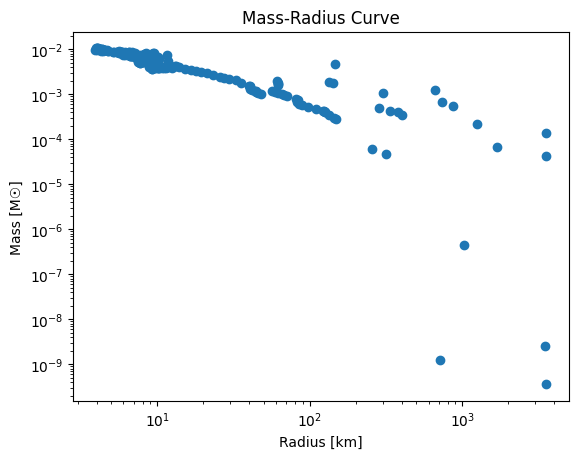

In [45]:
import matplotlib.pyplot as plt

radii, masses = generate_mass_radius_curve(0, 5)

fig, ax1 = plt.subplots()
ax1.scatter(radii, masses)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel("Mass [M☉]")
ax1.set_xlabel("Radius [km]")
ax1.set_title("Mass-Radius Curve")

TEMP_GAMMA = np.float64(1.8690663709614028)
TEMP_K = np.float64(0.00018275415434762654) [MeV-fm units]


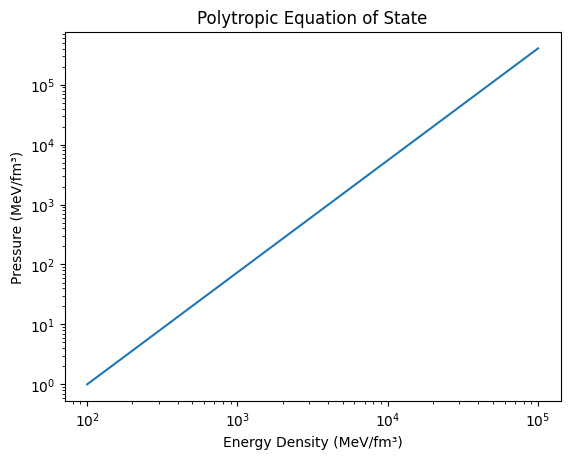

In [43]:
import numpy as np
import matplotlib.pyplot as plt

EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3

eps1, p1 = EOS_POINT_1
eps2, p2 = EOS_POINT_2

TEMP_GAMMA = np.log10(p2 / p1) / np.log10(eps2 / eps1)
TEMP_K = p1 / (eps1**TEMP_GAMMA)


@np.vectorize
def eos_p(eps: float):
    return TEMP_K * eps**TEMP_GAMMA


epsilons = np.logspace(2, 5, 200)
pressures = eos_p(epsilons)

fig, ax1 = plt.subplots()

ax1.loglog(epsilons, pressures)
ax1.set_xlabel("Energy Density (MeV/fm³)")
ax1.set_ylabel("Pressure (MeV/fm³)")
ax1.set_title("Polytropic Equation of State")

print(f"{TEMP_GAMMA = }")
print(f"{TEMP_K = } [MeV-fm units]")

DEBUG: TEMP_GAMMA = np.float64(1.4952530967691224)
DEBUG: TEMP_K = np.float64(0.10221009841618742)


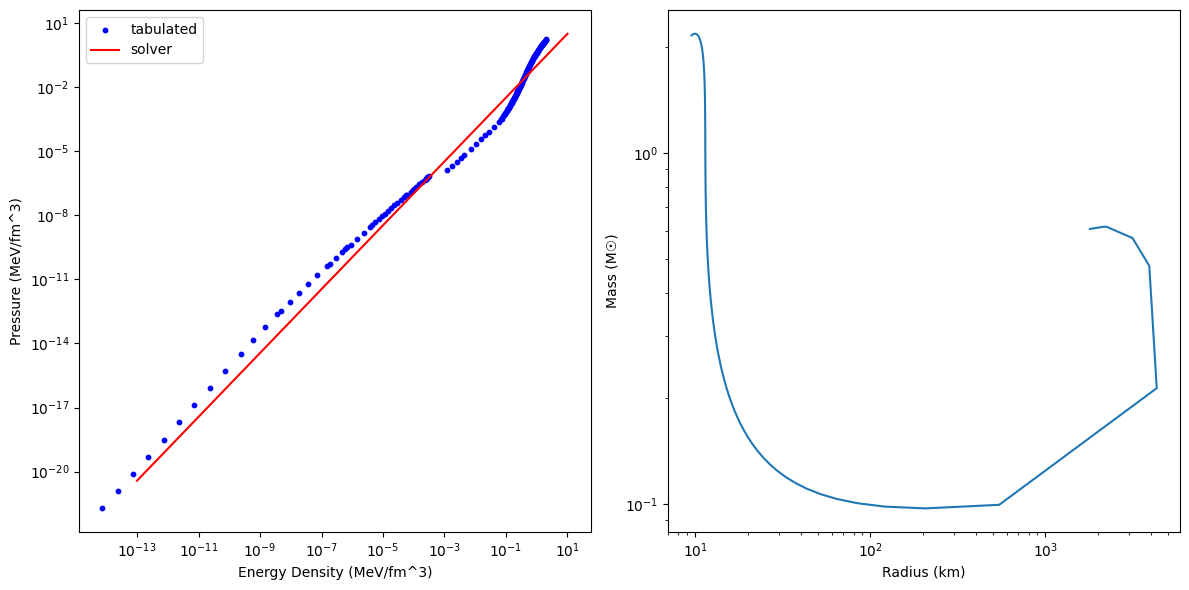

In [44]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

EOS_DATA_FILE_PATH = "eos_68.txt"
MASS_RADIUS_DATA_FILE_PATH = "mrl_eos_68.txt"

with open(EOS_DATA_FILE_PATH, 'r') as f:
    # Skip the comments are the start of the file
    pos = 0
    while f.readline().startswith("#"):
        pos = f.tell()
    f.seek(pos) # Go back 1 line.
    mrl_df = pd.read_table(f)
tabulated_p_values = mrl_df['p']
tabulated_eps_values = mrl_df['e']

with open(MASS_RADIUS_DATA_FILE_PATH, 'r') as f:
    # Skip the comments are the start of the file
    pos = 0
    while f.readline().startswith("#"):
        pos = f.tell()
    f.seek(pos)  # Go back 1 line.
    mrl_df = pd.read_table(f, sep=' ')
tabulated_m_values = mrl_df['m']
tabulated_r_values = mrl_df['r']

solver_eps_values = np.logspace(-13, 1)
EOS_POINT_1 = (100, 1)  # (ε, P) in MeV/fm^3
EOS_POINT_2 = (180, 3)  # (ε, P) in MeV/fm^3

eps1, p1 = EOS_POINT_1
eps2, p2 = EOS_POINT_2

TEMP_GAMMA = np.log10(p2 / p1) / np.log10(eps2 / eps1)
TEMP_GAMMA *= 0.8
TEMP_K = p1 / (eps1**TEMP_GAMMA)
TEMP_K *= 100
def temp_p(eps): return TEMP_K * eps ** TEMP_GAMMA
solver_p_values = temp_p(solver_eps_values)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(12, 6)

ax1: Axes = ax1
ax1.scatter(tabulated_eps_values, tabulated_p_values, color = 'blue', label = 'tabulated', s=10)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.loglog(solver_eps_values, solver_p_values, color = 'red', label = 'solver')
ax1.set_xlabel("Energy Density (MeV/fm^3)")
ax1.set_ylabel("Pressure (MeV/fm^3)")
ax1.legend()

ax2.loglog(tabulated_r_values, tabulated_m_values)
ax2.set_xlabel("Radius (km)")
ax2.set_ylabel("Mass (M☉)")

fig.tight_layout()

print(f"DEBUG: {TEMP_GAMMA = }")
print(f"DEBUG: {TEMP_K = }")
